In [1]:
!pip install pandas numpy matplotlib scikit-learn lifelines scikit-survival openpyxl


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 78.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 110.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ee6bc1e267c994f010dfeb41232e3657c23d917c23153fe92c33d38cc8a50762
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
# ==========================================
# CELL 1: Install & Import Libraries
# ==========================================

# Uncomment if first time running
# !pip install pandas numpy matplotlib scikit-learn lifelines scikit-survival openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score
)

import warnings
warnings.filterwarnings("ignore")

# Global configuration
N_REPEATS = 25
RANDOM_STATE_BASE = 42
TIME_GRID = np.arange(0.25, 5.0, 0.25)

print("Enhanced Survival Pipeline Initialized")


Enhanced Survival Pipeline Initialized


In [3]:
# ==========================================
# CELL 2: Load & Preprocess Data
# ==========================================

file_path = r"/kaggle/input/datasets/sweta2000/umhs-dataset/Training.xlsx"

data = pd.read_excel(file_path)

# Encode categorical variables
data["Race"] = np.where(data["Race"] == "Caucasian", 1, 0)
data["Smoking"] = np.where(data["Smoking"] == "Current", 1, 0)
data["Alcohol"] = np.where(data["Alcohol"] == "Yes", 1, 0)
data["Drug"] = np.where(data["Drug"] == "Yes", 1, 0)

# Convert numeric safely
data["HGB"] = pd.to_numeric(data["HGB"], errors="coerce")
data["Duration"] = pd.to_numeric(data["Duration"], errors="coerce")
data["EndEvent"] = pd.to_numeric(data["EndEvent"], errors="coerce")
data["MAGGIC"] = pd.to_numeric(data["MAGGIC"], errors="coerce")

# Create survival columns
data["time"] = data["Duration"]
data["event"] = data["EndEvent"]

data.drop(columns=["Duration", "EndEvent"], inplace=True)

data = data.loc[:, ~data.columns.duplicated()]

print("Data Loaded. Shape:", data.shape)


Data Loaded. Shape: (343, 157)


In [4]:
# ==========================================
# CELL 3: Create D, M, DM subsets (GBSA)
# ==========================================

# Get column list
cols = list(data.columns)

# Find index positions
idx_race = cols.index("Race")
idx_c_sa = cols.index("C_SA")
idx_rvpower_s = cols.index("RVpowerIndex_S")

# ------------------------------------------
# D
# ------------------------------------------
D = pd.concat([
    data.iloc[:, idx_race:idx_c_sa],
    data[["time", "event"]]
], axis=1)

# ------------------------------------------
# M
# ------------------------------------------
M = pd.concat([
    data.iloc[:, idx_c_sa:idx_rvpower_s + 1],
    data[["time", "event"]]
], axis=1)

# ------------------------------------------
# DM
# ------------------------------------------
DM = pd.concat([
    data.iloc[:, idx_race:idx_rvpower_s + 1],
    data[["time", "event"]]
], axis=1)

# ------------------------------------------
# Remove duplicate columns (important)
# ------------------------------------------
D = D.loc[:, ~D.columns.duplicated()]
M = M.loc[:, ~M.columns.duplicated()]
DM = DM.loc[:, ~DM.columns.duplicated()]

# ------------------------------------------
# Print shapes
# ------------------------------------------
print("D:", D.shape)
print("M:", M.shape)
print("DM:", DM.shape)

D: (343, 69)
M: (343, 82)
DM: (343, 149)


In [5]:
from collections import defaultdict
from sklearn.inspection import permutation_importance

def rsf_variable_hunting(dataset, model_name, n_repeats=25):

    print(f"\nStarting Variable Hunting for {model_name}")
    #Get feature names
    feature_names = list(dataset.columns)
    feature_names.remove("time")
    feature_names.remove("event")
    #Initialize counters: How often each feature is selected across repetitions.
    freq_counter = defaultdict(int)
    importance_counter = defaultdict(float)
    #Preparing training data
    X_full = dataset.drop(columns=["time", "event"])
    y_full = Surv.from_dataframe("event", "time", dataset)

    for rep in range(n_repeats):

        print(f"{model_name} Repeat {rep+1}/{n_repeats}")

        rsf = RandomSurvivalForest(
            n_estimators=100,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE_BASE + rep
        )

        rsf.fit(X_full, y_full)

        # Compute permutation importance 
        perm = permutation_importance(
            rsf,
            X_full,
            y_full,
            n_repeats=5,
            random_state=RANDOM_STATE_BASE + rep,
            n_jobs=-1
        )

        importances = perm.importances_mean

        importance_dict = dict(zip(X_full.columns, importances))

        threshold = np.mean(importances)

        selected_features = [
            feature for feature, imp in importance_dict.items()
            if imp >= threshold
        ]

        for feature in selected_features:

            freq_counter[feature] += 1
            importance_counter[feature] += importance_dict[feature]

    avg_importance = {
        feature: importance_counter[feature] / n_repeats
        for feature in importance_counter
    }

    sorted_features = sorted(
        avg_importance.items(),
        key=lambda x: x[1],
        reverse=True
    )

    sorted_features_dict = dict(sorted_features)

    print(f"\nCompleted Variable Hunting for {model_name}")

    return {
        "frequency": dict(freq_counter),
        "importance": sorted_features_dict
    }

In [6]:
result_D = rsf_variable_hunting(D, "D", N_REPEATS)
result_M = rsf_variable_hunting(M, "M", N_REPEATS)
result_DM = rsf_variable_hunting(DM, "DM", N_REPEATS)


Starting Variable Hunting for D
D Repeat 1/25
D Repeat 2/25
D Repeat 3/25
D Repeat 4/25
D Repeat 5/25
D Repeat 6/25
D Repeat 7/25
D Repeat 8/25
D Repeat 9/25
D Repeat 10/25
D Repeat 11/25
D Repeat 12/25
D Repeat 13/25
D Repeat 14/25
D Repeat 15/25
D Repeat 16/25
D Repeat 17/25
D Repeat 18/25
D Repeat 19/25
D Repeat 20/25
D Repeat 21/25
D Repeat 22/25
D Repeat 23/25
D Repeat 24/25
D Repeat 25/25

Completed Variable Hunting for D

Starting Variable Hunting for M
M Repeat 1/25
M Repeat 2/25
M Repeat 3/25
M Repeat 4/25
M Repeat 5/25
M Repeat 6/25
M Repeat 7/25
M Repeat 8/25
M Repeat 9/25
M Repeat 10/25
M Repeat 11/25
M Repeat 12/25
M Repeat 13/25
M Repeat 14/25
M Repeat 15/25
M Repeat 16/25
M Repeat 17/25
M Repeat 18/25
M Repeat 19/25
M Repeat 20/25
M Repeat 21/25
M Repeat 22/25
M Repeat 23/25
M Repeat 24/25
M Repeat 25/25

Completed Variable Hunting for M

Starting Variable Hunting for DM
DM Repeat 1/25
DM Repeat 2/25
DM Repeat 3/25
DM Repeat 4/25
DM Repeat 5/25
DM Repeat 6/25
DM Repeat 

In [7]:
print("\nTop features in D:")
print(list(result_D["importance"].items())[:10])

print("\nTop features in M:")
print(list(result_M["importance"].items())[:10])

print("\nTop features in DM:")
print(list(result_DM["importance"].items())[:10])


Top features in D:
[('HGB', np.float64(0.025959414952013322)), ('Creatinine', np.float64(0.010739951127952691)), ('EAr_D', np.float64(0.00811077664057797)), ('CO_D', np.float64(0.007957785883769527)), ('Age', np.float64(0.006510889967064492)), ('RAPmax_D', np.float64(0.004977865920600636)), ('DBP_D', np.float64(0.004686900166448288)), ('RVEDV_D', np.float64(0.0041378333392357615)), ('PASP_D', np.float64(0.004016007366221624)), ('RVSWI_D', np.float64(0.003988525693239372))]

Top features in M:
[('PVR_S', np.float64(0.005179303750398414)), ('B_P', np.float64(0.005156355136877146)), ('R_tSA', np.float64(0.004544675425859694)), ('LVpower_S', np.float64(0.004241527074405923)), ('R_PA', np.float64(0.003703509579629567)), ('MVmg_S', np.float64(0.0036111484931118727)), ('EAr_S', np.float64(0.003485356093069385)), ('R_t_c', np.float64(0.003404327655204165)), ('RVEDV_S', np.float64(0.003320749371392147)), ('R_a_o', np.float64(0.0033071501930091725))]

Top features in DM:
[('HGB', np.float64(0.0

In [8]:
result_D
result_M
result_DM

{'frequency': {'Age': 25,
  'BMI': 11,
  'HGB': 25,
  'Creatinine': 25,
  'NYHA class': 16,
  'HR': 7,
  'DM': 16,
  'Renal failure': 18,
  'BNP': 14,
  "Septal E/e'": 14,
  "Lateral E/e'": 15,
  'SBP_D': 12,
  'DBP_D': 22,
  'RAPmax_D': 16,
  'CO_D': 15,
  'LVEDV_D': 9,
  'LVESV_D': 6,
  'RVEDV_D': 17,
  'EAr_D': 19,
  'PVR_D': 15,
  'RVSWI_D': 13,
  'C_SA': 2,
  'k_act_RV': 8,
  'k_pas_LV': 20,
  'Vw_LV': 8,
  'B_P': 25,
  'R_SA': 7,
  'R_PA': 24,
  'R_tSA': 23,
  'R_RA': 22,
  'R_LA': 22,
  'R_p_o': 21,
  'R_p_c': 12,
  'R_m_o': 20,
  'R_m_c': 14,
  'R_a_o': 18,
  'SBP_S': 8,
  'minRVP_S': 13,
  'RVm_S': 6,
  'RVEDV_S': 18,
  'RVESV_S': 10,
  'LAVmax_S': 8,
  'LVESP_S': 16,
  'MVr_S': 8,
  'MVmg_S': 23,
  'AVpg_S': 15,
  'PVpg_S': 19,
  'EAr_S': 19,
  'StressRV_S': 13,
  'RVMD_S': 13,
  'LVpower_S': 20,
  'RVpower_S': 12,
  'RVSWI_S': 8,
  'PVR_S': 24,
  'SVR_S': 6,
  'LVpowerIndex_S': 11,
  'RVpowerIndex_S': 14,
  'AF': 8,
  'COPD': 2,
  'RVEDP_D': 6,
  'minRVP_D': 9,
  'LVIDd_D': 

In [9]:
def extract_feature_groups(result, n_repeats=25):

    freq = result["frequency"]
    importance = result["importance"]

    # Mandatory features: ≥80% frequency
    mandatory = [
        feature for feature, count in freq.items()
        if count >= 0.8 * n_repeats
    ]

    # Valid features: ≥5 repeats
    valid = [
        feature for feature, count in freq.items()
        if count >= 5
    ]

    # Sorted valid features by importance
    sorted_valid = {
        feature: importance[feature]
        for feature in valid
        if feature in importance
    }

    sorted_valid = dict(
        sorted(sorted_valid.items(),
               key=lambda x: x[1],
               reverse=True)
    )

    return mandatory, valid, sorted_valid


mandatory_D, valid_D, sorted_valid_D = extract_feature_groups(result_D)
mandatory_M, valid_M, sorted_valid_M = extract_feature_groups(result_M)
mandatory_DM, valid_DM, sorted_valid_DM = extract_feature_groups(result_DM)


print("\nMandatory D:", len(mandatory_D))
print("Valid D:", len(valid_D))

print("\nMandatory M:", len(mandatory_M))
print("Valid M:", len(valid_M))

print("\nMandatory DM:", len(mandatory_DM))
print("Valid DM:", len(valid_DM))


Mandatory D: 16
Valid D: 33

Mandatory M: 18
Valid M: 51

Mandatory DM: 15
Valid DM: 98


In [10]:
def train_rsf_model(dataset, features, random_state):

    X = dataset[features]
    y = Surv.from_dataframe("event", "time", dataset)

    rsf = RandomSurvivalForest(
        n_estimators=100,
        min_samples_split=10,
        min_samples_leaf=15,
        max_features="sqrt",
        n_jobs=-1,
        random_state=random_state
    )

    rsf.fit(X, y)

    risk_scores = rsf.predict(X)

    cindex = concordance_index_censored(
        dataset["event"].astype(bool),
        dataset["time"],
        risk_scores
    )[0]

    return cindex

In [11]:
def find_best_features(dataset, sorted_valid_features, mandatory_features,
                       model_name, max_additional=12, repeats=10):

    print(f"\nSelecting best features for {model_name}")

    selected = mandatory_features.copy()
    remaining = list(sorted_valid_features.keys())

    remaining = [f for f in remaining if f not in selected]

    history = []

    # Evaluate mandatory features first
    scores = []

    for rep in range(repeats):

        cindex = train_rsf_model(
            dataset,
            selected,
            RANDOM_STATE_BASE + rep
        )

        scores.append(cindex)

    best_score = np.mean(scores)

    history.append((len(selected), best_score, selected.copy()))

    print(f"Initial features: {len(selected)} | C-index: {best_score:.4f}")

    # Forward selection
    for i in range(max_additional):

        best_feature = None
        best_feature_score = best_score

        for feature in remaining:

            test_features = selected + [feature]

            scores = []

            for rep in range(repeats):

                cindex = train_rsf_model(
                    dataset,
                    test_features,
                    RANDOM_STATE_BASE + rep
                )

                scores.append(cindex)

            mean_score = np.mean(scores)

            if mean_score > best_feature_score:

                best_feature_score = mean_score
                best_feature = feature

        if best_feature is None:
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        best_score = best_feature_score

        history.append((len(selected), best_score, selected.copy()))

        print(f"Added: {best_feature} | Total: {len(selected)} | C-index: {best_score:.4f}")

    return selected, history

In [12]:
selected_D, history_D = find_best_features(
    D, sorted_valid_D, mandatory_D, "D"
)

selected_M, history_M = find_best_features(
    M, sorted_valid_M, mandatory_M, "M"
)

selected_DM, history_DM = find_best_features(
    DM, sorted_valid_DM, mandatory_DM, "DM"
)

print("\nFinal selected features:")
print("D:", len(selected_D))
print("M:", len(selected_M))
print("DM:", len(selected_DM))


Selecting best features for D
Initial features: 16 | C-index: 0.8383
Added: DM | Total: 17 | C-index: 0.8418
Added: RVESV_D | Total: 18 | C-index: 0.8451
Added: LVIDd_D | Total: 19 | C-index: 0.8452
Added: HR | Total: 20 | C-index: 0.8471
Added: EF_D | Total: 21 | C-index: 0.8495
Added: minRVP_D | Total: 22 | C-index: 0.8504
Added: Septal E/e' | Total: 23 | C-index: 0.8520
Added: NYHA class | Total: 24 | C-index: 0.8526
Added: LVESV_D | Total: 25 | C-index: 0.8531
Added: BMI | Total: 26 | C-index: 0.8534

Selecting best features for M
Initial features: 18 | C-index: 0.8243
Added: PADP_S | Total: 19 | C-index: 0.8275
Added: LVIDd_S | Total: 20 | C-index: 0.8306
Added: K_P | Total: 21 | C-index: 0.8318
Added: PVr_S | Total: 22 | C-index: 0.8322
Added: DBP_S | Total: 23 | C-index: 0.8338
Added: R_p_c | Total: 24 | C-index: 0.8366
Added: k_act_RV | Total: 25 | C-index: 0.8367
Added: Amref_SEP | Total: 26 | C-index: 0.8397
Added: LAVmax_S | Total: 27 | C-index: 0.8421
Added: RVMD_S | Total

In [13]:
# ==========================================
# CELL: Train-Test Split (Training dataset)
# ==========================================

from sklearn.model_selection import train_test_split

def split_dataset(dataset, selected_features, model_name, test_size=0.3):

    print(f"\nSplitting dataset for {model_name}")

    X = dataset[selected_features]
    y = Surv.from_dataframe("event", "time", dataset)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    print(f"{model_name} Train shape:", X_train.shape)
    print(f"{model_name} Test shape:", X_test.shape)

    return X_train, X_test, y_train, y_test


# Split each dataset
X_train_D, X_test_D, y_train_D, y_test_D = split_dataset(D, selected_D, "D")
X_train_M, X_test_M, y_train_M, y_test_M = split_dataset(M, selected_M, "M")
X_train_DM, X_test_DM, y_train_DM, y_test_DM = split_dataset(DM, selected_DM, "DM")


Splitting dataset for D
D Train shape: (240, 26)
D Test shape: (103, 26)

Splitting dataset for M
M Train shape: (240, 30)
M Test shape: (103, 30)

Splitting dataset for DM
DM Train shape: (240, 21)
DM Test shape: (103, 21)


In [14]:
# ==========================================
# CELL: Hyperparameter tuning with Cross-Validation
# ==========================================

from sklearn.model_selection import KFold, ParameterGrid

def tune_rsf_cv(X_train, y_train, model_name, n_splits=5):

    print(f"\nHyperparameter tuning with CV for {model_name}")

    param_grid = {
        "n_estimators": [500, 1000],
        "min_samples_leaf": [5, 10, 15],
        "max_features": ["sqrt", 0.3, 0.5]
    }

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    best_score = -1
    best_params = None

    for params in ParameterGrid(param_grid):

        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

            X_fold_train = X_train.iloc[train_idx]
            X_fold_val   = X_train.iloc[val_idx]

            y_fold_train = y_train[train_idx]
            y_fold_val   = y_train[val_idx]

            rsf = RandomSurvivalForest(
                **params,
                n_jobs=-1,
                random_state=42
            )

            # Train on fold training data
            rsf.fit(X_fold_train, y_fold_train)

            # Predict on fold validation data
            risk_scores = rsf.predict(X_fold_val)

            cindex = concordance_index_censored(
                y_fold_val["event"],
                y_fold_val["time"],
                risk_scores
            )[0]

            fold_scores.append(cindex)

        mean_score = np.mean(fold_scores)
        std_score  = np.std(fold_scores)

        print(f"{params} → Mean CV C-index: {mean_score:.4f} (±{std_score:.4f})")

        if mean_score > best_score:

            best_score = mean_score
            best_params = params

    print(f"\nBest params for {model_name}:")
    print(best_params)
    print(f"Best CV C-index: {best_score:.4f}")

    return best_params


# Run CV tuning
best_params_D  = tune_rsf_cv(X_train_D,  y_train_D,  "D")
best_params_M  = tune_rsf_cv(X_train_M,  y_train_M,  "M")
best_params_DM = tune_rsf_cv(X_train_DM, y_train_DM, "DM")


Hyperparameter tuning with CV for D
{'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500} → Mean CV C-index: 0.7346 (±0.0540)
{'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 1000} → Mean CV C-index: 0.7355 (±0.0557)
{'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 500} → Mean CV C-index: 0.7310 (±0.0577)
{'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 1000} → Mean CV C-index: 0.7273 (±0.0578)
{'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 500} → Mean CV C-index: 0.7211 (±0.0531)
{'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 1000} → Mean CV C-index: 0.7235 (±0.0602)
{'max_features': 0.3, 'min_samples_leaf': 5, 'n_estimators': 500} → Mean CV C-index: 0.7305 (±0.0525)
{'max_features': 0.3, 'min_samples_leaf': 5, 'n_estimators': 1000} → Mean CV C-index: 0.7272 (±0.0565)
{'max_features': 0.3, 'min_samples_leaf': 10, 'n_estimators': 500} → Mean CV C-index: 0.7259 (±0.0623)
{'max_features': 0

In [15]:
# ==========================================
# CELL: Final RSF training and evaluation on TEST set
# ==========================================

def train_and_evaluate_test(X_train, y_train,
                            X_test, y_test,
                            best_params, model_name):

    print(f"\nFinal RSF training and testing for {model_name}")

    # Train model on TRAIN data
    rsf = RandomSurvivalForest(
        **best_params,
        n_jobs=-1,
        random_state=42
    )

    rsf.fit(X_train, y_train)

    # Predict on TEST data
    risk_scores = rsf.predict(X_test)

    # ==========================================
    # C-index
    # ==========================================
    cindex = concordance_index_censored(
        y_test["event"],
        y_test["time"],
        risk_scores
    )[0]

    # ==========================================
    # Dynamic time grid
    # ==========================================
    max_time = min(y_train["time"].max(), y_test["time"].max())

    valid_times = np.linspace(
        y_test["time"].min() + 1e-6,
        max_time * 0.99,
        20
    )

    # ==========================================
    # iAUC
    # ==========================================
    auc_times, auc_scores = cumulative_dynamic_auc(
        y_train,
        y_test,
        risk_scores,
        valid_times
    )

    iauc = np.mean(auc_scores)

    # ==========================================
    # Brier score
    # ==========================================
    surv_funcs = rsf.predict_survival_function(X_test)

    surv_matrix = np.row_stack([
        fn(valid_times) for fn in surv_funcs
    ])

    brier = integrated_brier_score(
        y_train,
        y_test,
        surv_matrix,
        valid_times
    )

    # Print results
    print(f"\n{model_name} TEST Results:")
    print(f"C-index: {cindex:.4f}")
    print(f"iAUC:    {iauc:.4f}")
    print(f"Brier:   {brier:.4f}")

    return rsf, cindex, iauc, brier


# ==========================================
# Run for all models
# ==========================================

model_D, cindex_D, iauc_D, brier_D = train_and_evaluate_test(
    X_train_D, y_train_D,
    X_test_D, y_test_D,
    best_params_D,
    "D"
)

model_M, cindex_M, iauc_M, brier_M = train_and_evaluate_test(
    X_train_M, y_train_M,
    X_test_M, y_test_M,
    best_params_M,
    "M"
)

model_DM, cindex_DM, iauc_DM, brier_DM = train_and_evaluate_test(
    X_train_DM, y_train_DM,
    X_test_DM, y_test_DM,
    best_params_DM,
    "DM"
)


Final RSF training and testing for D

D TEST Results:
C-index: 0.7072
iAUC:    0.7255
Brier:   0.1547

Final RSF training and testing for M

M TEST Results:
C-index: 0.6615
iAUC:    0.7086
Brier:   0.1631

Final RSF training and testing for DM

DM TEST Results:
C-index: 0.7551
iAUC:    0.7781
Brier:   0.1505


In [16]:
# ==========================================
# Compute Time-Dependent AUC Curves (RSF Test)
# ==========================================

def compute_rsf_auc_curve(model,
                          X_train, y_train,
                          X_test, y_test):

    # Risk scores
    risk_scores = model.predict(X_test)

    # Safe time grid (inside follow-up)
    max_time = min(y_train["time"].max(), y_test["time"].max())

    times = np.linspace(
        y_test["time"].min() + 1e-6,
        max_time * 0.99,
        50
    )

    result = cumulative_dynamic_auc(
        y_train,
        y_test,
        risk_scores,
        times
    )

    auc_curve = result[0]   # based on your environment

    return times, auc_curve


# Compute for each model
times_D_rsf, auc_D_rsf = compute_rsf_auc_curve(
    model_D, X_train_D, y_train_D, X_test_D, y_test_D
)

times_M_rsf, auc_M_rsf = compute_rsf_auc_curve(
    model_M, X_train_M, y_train_M, X_test_M, y_test_M
)

times_DM_rsf, auc_DM_rsf = compute_rsf_auc_curve(
    model_DM, X_train_DM, y_train_DM, X_test_DM, y_test_DM
)

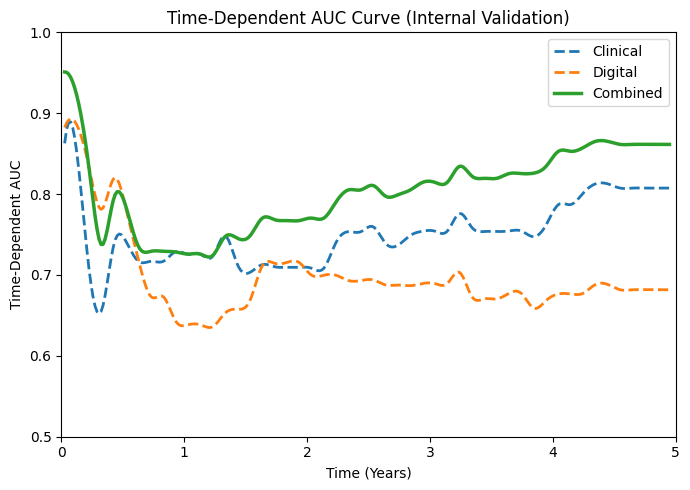

In [18]:
from scipy.interpolate import make_interp_spline

def smooth_curve(x, y, points=300):
    x_new = np.linspace(x.min(), x.max(), points)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_new)
    return x_new, y_smooth

# Smooth
tD_s, aD_s = smooth_curve(times_D_rsf, auc_D_rsf)
tM_s, aM_s = smooth_curve(times_M_rsf, auc_M_rsf)
tDM_s, aDM_s = smooth_curve(times_DM_rsf, auc_DM_rsf)

plt.figure(figsize=(7,5))

# Dotted for Clinical & Digital
plt.plot(tD_s, aD_s, linestyle='--', linewidth=2, label="Clinical")
plt.plot(tM_s, aM_s, linestyle='--', linewidth=2, label="Digital")

# Solid for Combined
plt.plot(tDM_s, aDM_s, linewidth=2.5, label="Combined")

plt.xlabel("Time (Years)")
plt.ylabel("Time-Dependent AUC")
plt.title("Time-Dependent AUC Curve (Internal Validation)")

plt.ylim(0.5, 1.0)
plt.xlim(0, 5)

plt.legend()

# Full box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

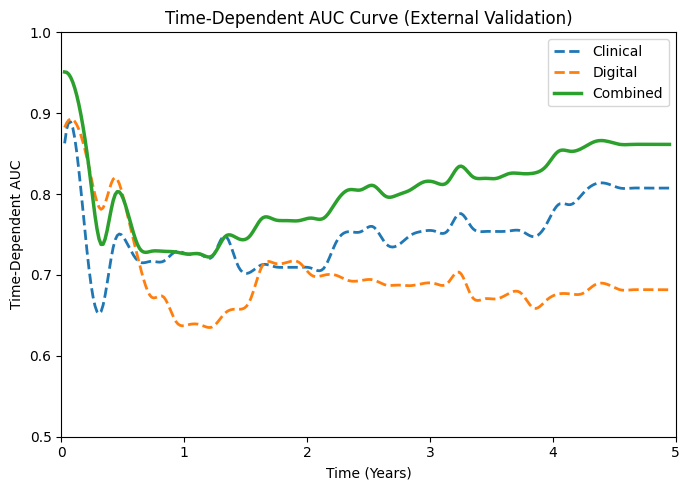

In [23]:
from scipy.interpolate import make_interp_spline

def smooth_curve(x, y, points=300):
    x_new = np.linspace(x.min(), x.max(), points)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_new)
    return x_new, y_smooth

# Smooth
tD_s, aD_s = smooth_curve(times_D_rsf, auc_D_rsf)
tM_s, aM_s = smooth_curve(times_M_rsf, auc_M_rsf)
tDM_s, aDM_s = smooth_curve(times_DM_rsf, auc_DM_rsf)

plt.figure(figsize=(7,5))

# Dotted for Clinical & Digital
plt.plot(tD_s, aD_s, linestyle='--', linewidth=2, label="Clinical")
plt.plot(tM_s, aM_s, linestyle='--', linewidth=2, label="Digital")

# Solid for Combined
plt.plot(tDM_s, aDM_s, linewidth=2.5, label="Combined")

plt.xlabel("Time (Years)")
plt.ylabel("Time-Dependent AUC")
plt.title("Time-Dependent AUC Curve (External Validation)")

plt.ylim(0.5, 1.0)
plt.xlim(0, 5)

plt.legend()

# Full box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

In [19]:
test_data = pd.read_excel("/kaggle/input/datasets/sweta2000/umhs-dataset/Testing.xlsx")

# Apply SAME preprocessing
test_data["Race"] = np.where(test_data["Race"] == "Caucasian", 1, 0)
test_data["Smoking"] = np.where(test_data["Smoking"] == "Current", 1, 0)
test_data["Alcohol"] = np.where(test_data["Alcohol"] == "Yes", 1, 0)
test_data["Drug"] = np.where(test_data["Drug"] == "Yes", 1, 0)

test_data["time"] = test_data["Duration"]
test_data["event"] = test_data["EndEvent"]

test_data.drop(columns=["Duration", "EndEvent"], inplace=True)

In [20]:
# ==========================================
# CELL: Final RSF training and evaluation on EXTERNAL dataset
# ==========================================

def train_and_evaluate_external(train_dataset, test_dataset,
                                selected_features, best_params,
                                model_name):

    print(f"\nFINAL RSF Training and External Evaluation: {model_name}")

    # Prepare training data
    X_train = train_dataset[selected_features]
    y_train = Surv.from_dataframe("event", "time", train_dataset)

    # Prepare external test data
    X_test = test_dataset[selected_features]
    y_test = Surv.from_dataframe("event", "time", test_dataset)

    # Train final model on FULL training dataset
    rsf = RandomSurvivalForest(
        **best_params,
        n_jobs=-1,
        random_state=42
    )

    rsf.fit(X_train, y_train)

    # Predict on EXTERNAL dataset
    risk_scores = rsf.predict(X_test)

    # ==========================================
    # C-index
    # ==========================================
    cindex = concordance_index_censored(
        y_test["event"],
        y_test["time"],
        risk_scores
    )[0]

    # ==========================================
    # Dynamic valid time grid
    # ==========================================
    max_time = min(y_train["time"].max(), y_test["time"].max())

    valid_times = np.linspace(
        y_test["time"].min() + 1e-6,
        max_time * 0.99,
        20
    )

    # ==========================================
    # Time-dependent AUC (iAUC)
    # ==========================================
    auc_times, auc_scores = cumulative_dynamic_auc(
        y_train,
        y_test,
        risk_scores,
        valid_times
    )

    iauc = np.mean(auc_scores)

    # ==========================================
    # Integrated Brier Score
    # ==========================================
    surv_funcs = rsf.predict_survival_function(X_test)

    surv_matrix = np.row_stack([
        fn(valid_times) for fn in surv_funcs
    ])

    brier = integrated_brier_score(
        y_train,
        y_test,
        surv_matrix,
        valid_times
    )

    # ==========================================
    # Print results
    # ==========================================
    print(f"\n{model_name} External Results:")
    print(f"C-index: {cindex:.4f}")
    print(f"iAUC:    {iauc:.4f}")
    print(f"Brier:   {brier:.4f}")

    return rsf, cindex, iauc, brier


# ==========================================
# Run for all models
# ==========================================

model_D, cindex_D, iauc_D, brier_D = train_and_evaluate_external(
    data, test_data,
    selected_D,
    best_params_D,
    "D"
)

model_M, cindex_M, iauc_M, brier_M = train_and_evaluate_external(
    data, test_data,
    selected_M,
    best_params_M,
    "M"
)

model_DM, cindex_DM, iauc_DM, brier_DM = train_and_evaluate_external(
    data, test_data,
    selected_DM,
    best_params_DM,
    "DM"
)


FINAL RSF Training and External Evaluation: D

D External Results:
C-index: 0.6069
iAUC:    0.6218
Brier:   0.2424

FINAL RSF Training and External Evaluation: M

M External Results:
C-index: 0.6085
iAUC:    0.5696
Brier:   0.2159

FINAL RSF Training and External Evaluation: DM

DM External Results:
C-index: 0.6687
iAUC:    0.6908
Brier:   0.2046


In [21]:
# ==========================================
# Compute RSF External Time-Dependent AUC Curves
# ==========================================

def compute_rsf_external_auc_curve(model,
                                   train_dataset, test_dataset,
                                   selected_features):

    X_train = train_dataset[selected_features]
    y_train = Surv.from_dataframe("event", "time", train_dataset)

    X_test = test_dataset[selected_features]
    y_test = Surv.from_dataframe("event", "time", test_dataset)

    # Risk scores
    risk_scores = model.predict(X_test)

    # 🔴 Strictly inside external follow-up
    t_min = y_test["time"].min()
    t_max = y_test["time"].max()

    times = np.linspace(
        t_min + 1e-6,
        t_max * 0.95,
        30
    )

    result = cumulative_dynamic_auc(
        y_train,
        y_test,
        risk_scores,
        times
    )

    auc_curve = result[0]

    return times, auc_curve


# Compute curves
times_D_ext, auc_D_ext = compute_rsf_external_auc_curve(
    model_D, data, test_data, selected_D
)

times_M_ext, auc_M_ext = compute_rsf_external_auc_curve(
    model_M, data, test_data, selected_M
)

times_DM_ext, auc_DM_ext = compute_rsf_external_auc_curve(
    model_DM, data, test_data, selected_DM
)

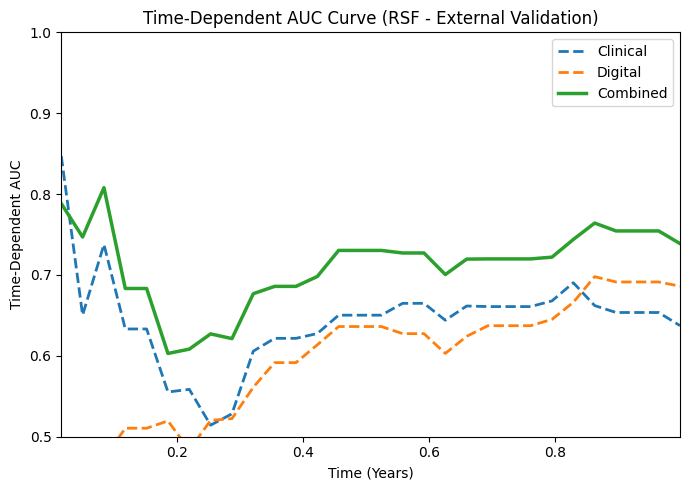

In [22]:
plt.figure(figsize=(7,5))

# Dotted for Clinical & Digital
plt.plot(times_D_ext, auc_D_ext, linestyle='--', linewidth=2, label="Clinical")
plt.plot(times_M_ext, auc_M_ext, linestyle='--', linewidth=2, label="Digital")

# Solid for Combined
plt.plot(times_DM_ext, auc_DM_ext, linewidth=2.5, label="Combined")

plt.xlabel("Time (Years)")
plt.ylabel("Time-Dependent AUC")
plt.title("Time-Dependent AUC Curve (RSF - External Validation)")

plt.ylim(0.5, 1.0)
plt.xlim(times_DM_ext.min(), times_DM_ext.max())

plt.legend()

# Full box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()